In [6]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
import umap


%reload_ext autoreload
%autoreload 2

from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import TwoSlopeNorm
from pathlib import Path
import glob

import networkx as nx
import seaborn as sns
from tes.DataUtils import DataUtils

# %matplotlib widget

In [25]:
data = pd.read_pickle("../../data/raw/PERI/itr_200.bz2")
u = umap.UMAP()

1. Fit the scaler as well as the reducer (u) (commented lines below) to a 'nice' timeseries with clear two different states.
2. Then comment out the fit lines, and use the fitting parameters to simply transform all new data (runs).
3. You should see the time segments getting nicely clustered into two states.
4. The time scale can be controlled using the chunk_size parameter. Smaller parameter value will detect states that last for shorter times. Larger values will require longer persistence within a state to be detected as distinct.

/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


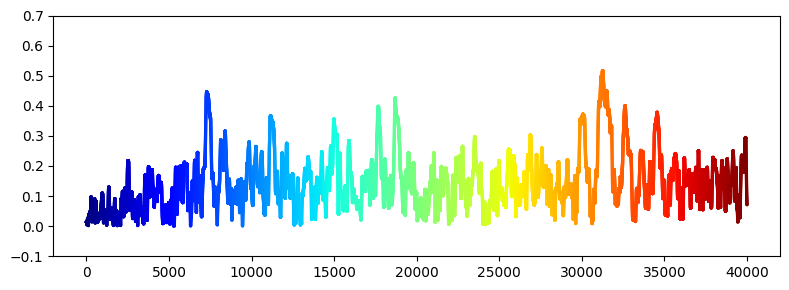

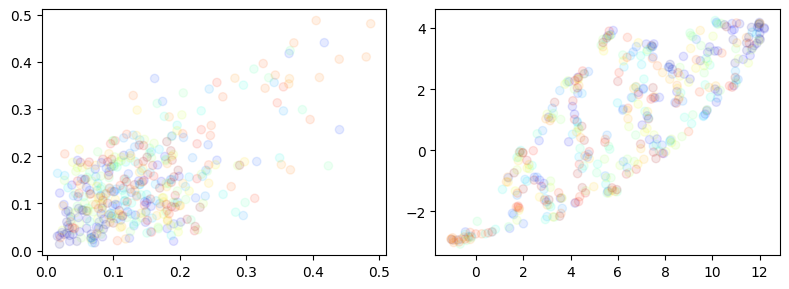

In [16]:
_data = data[37]
cmap = "jet"  # prism or jet

f, ax = plt.subplots(figsize=(8, 3), tight_layout=True)
ax.scatter(_data.index, _data, c=_data.index, s=2, cmap=cmap)
ax.set_ylim(-0.1, 0.7)

f, [ax, ax2] = plt.subplots(1, 2, figsize=(8, 3), tight_layout=True)
ax.scatter(
    _data[::100], _data.shift(100)[::100], alpha=0.1, c=_data[::100].index, cmap=cmap
)

chunk_size = 100
chunks = [_data[i : i + chunk_size] for i in range(0, len(_data), chunk_size)]

_s = StandardScaler().fit(chunks)
scaled_data = _s.transform(chunks)

_u = u.fit(scaled_data)
embedding = _u.transform(scaled_data)

ax2.scatter(
    embedding[:, 0], embedding[:, 1], c=range(len(chunks)), alpha=0.1, cmap=cmap
);

In [8]:
analyse.plot_global_synchrony(data[db_tr[-1]], 0.05)

NameError: name 'analyse' is not defined

In [11]:
analyse = AnalysisFunc()
reader = DataRead()
utils = DataUtils()

../../data/connectivity_matrix/mb_communities.npz already exists
DataUtils initialized


In [26]:
l = analyse.compute_param(data, 0.05)

Number of transitions / 100 iteration [0, 36, 76]
Number of transition [3, 5, 6, 8, 9, 12, 16, 18, 20, 25, 37, 43, 46, 47, 48, 52, 54, 55, 57, 59, 60, 62, 73, 75, 78, 79, 89, 90, 91, 93, 98, 100, 102, 108, 113, 114, 116, 118, 122, 124, 125, 127, 131, 132, 133, 138, 139, 141, 142, 148, 153, 156, 158, 159, 160, 169, 172, 176, 178, 181, 182, 183, 185, 186, 195]
Number of transition with more than one transition or a fall back [16, 43, 54, 62, 79, 98, 113, 116, 122, 125, 141, 153, 169, 172, 176, 182, 186]


In [13]:
db_tr = l["itr_st"]
# iterations which are not very fine with it: FN - 9,-1,

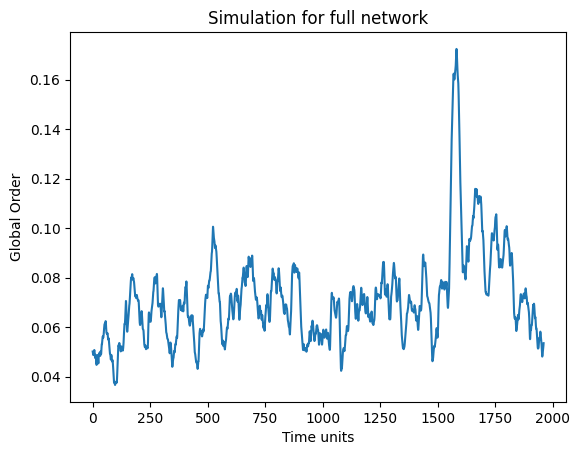

In [38]:
analyse.plot_global_synchrony(data[42], 0.05)